# Regression Multi Variable

In [1]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

import pandas as pd

df_housing = pd.DataFrame(housing.data,columns=housing.feature_names)
df_housing['target'] = housing.target
df_housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df_housing.shape

(20640, 9)

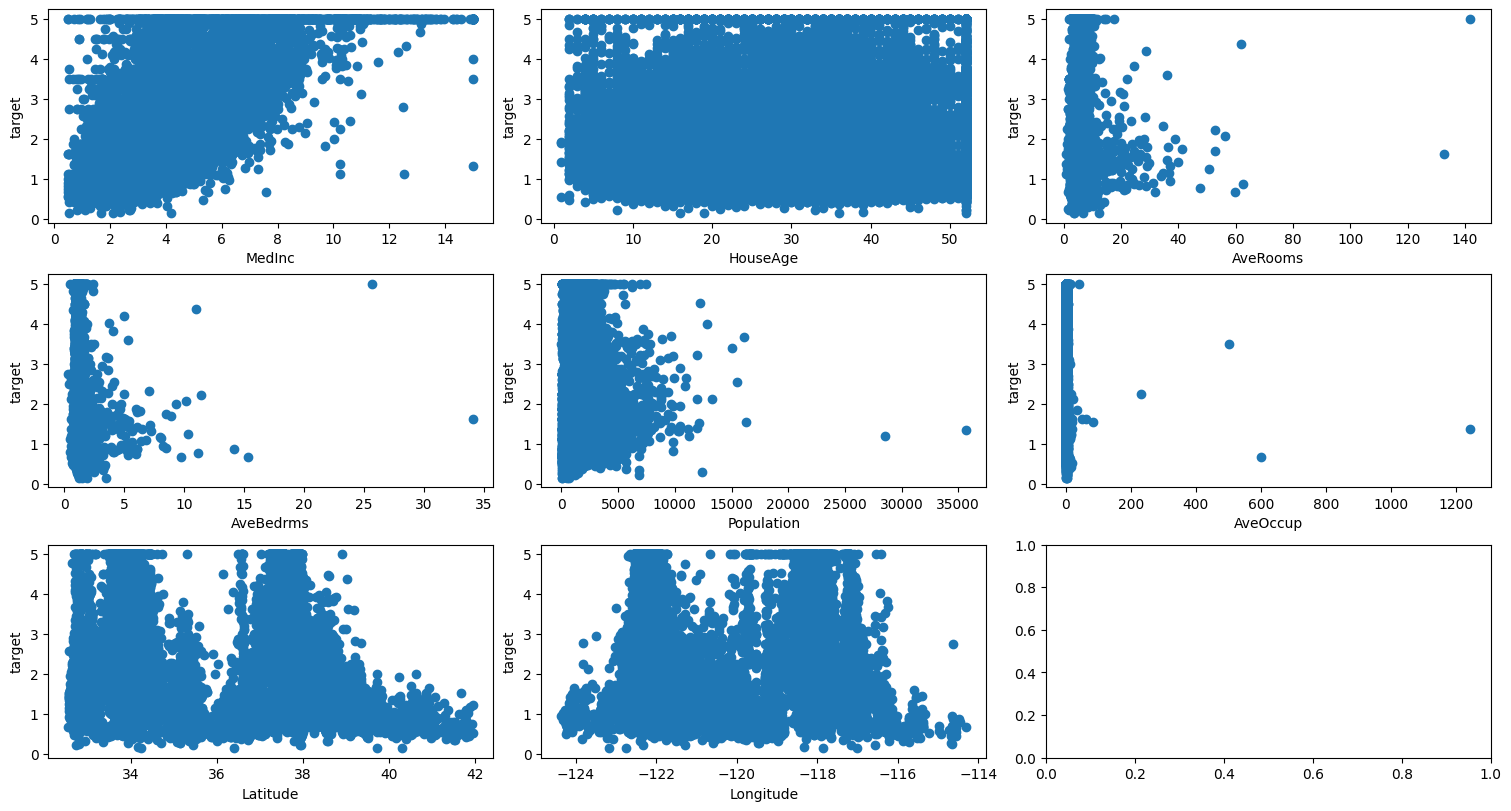

In [2]:
# visualize the relationship between the features and the response using scatterplots
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fig, axes = plt.subplots(3, 3,figsize=[15,8],constrained_layout=True)
axes = axes.flatten()
i=0
for x in df_housing.columns[:-1]:
    plt.sca(axes[i]) # set the current Axes
    plt.scatter(df_housing[x],df_housing.target)
    plt.xlabel(x)
    plt.ylabel("target")
    i+=1

plt.show()

<Axes: xlabel='HouseAge', ylabel='target'>

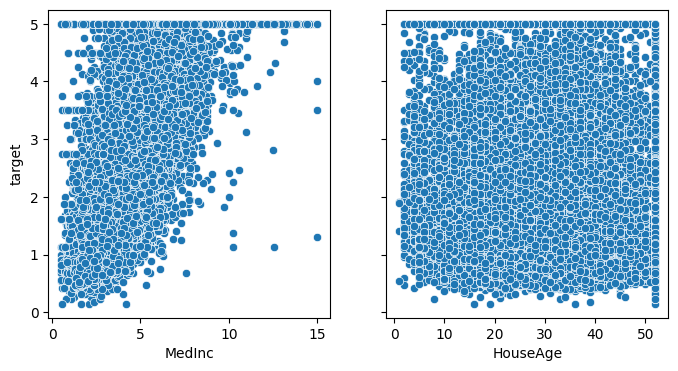

In [4]:
# call regplot on each axes
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True,figsize=[8,4])
sns.scatterplot(x=df_housing['MedInc'], y=df_housing.target, ax=ax1)
sns.scatterplot(x=df_housing['HouseAge'], y=df_housing.target, ax=ax2)

In [5]:
# This cell previously contained code specific to Boston Housing features (LSTAT, CRIM) which are not present in California Housing.
# It has been commented out to avoid errors.

# import numpy as np
# log_LSTAT=np.log(df_housing['LSTAT'])
# log_CRIM=np.log(df_housing['CRIM'])

# fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True,figsize=[8,4])
# sns.scatterplot(x=df_housing['LSTAT'], y=df_housing.target, ax=ax1)
# sns.scatterplot(x=log_LSTAT, y=df_housing.target, ax=ax2)

<Axes: xlabel='target', ylabel='Count'>

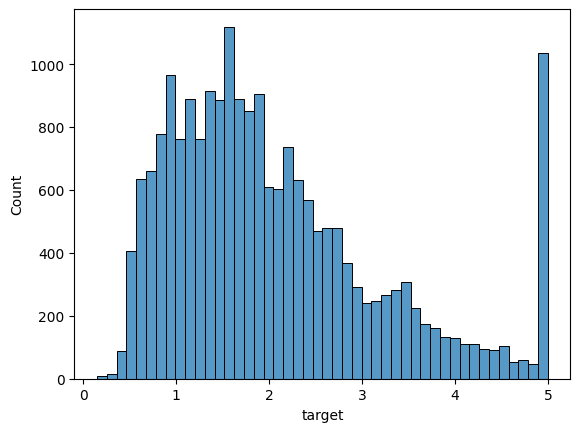

In [6]:
sns.histplot(data=df_housing, x='target')

In [7]:
#We can compute the correlation
df_housing.corr().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
MedInc,1.00,-0.12,0.33,-0.06,0.00,0.02,-0.08,-0.02,0.69
HouseAge,-0.12,1.00,-0.15,-0.08,-0.30,0.01,0.01,-0.11,0.11
AveRooms,0.33,-0.15,1.00,0.85,-0.07,-0.00,0.11,-0.03,0.15
AveBedrms,-0.06,-0.08,0.85,1.00,-0.07,-0.01,0.07,0.01,-0.05
Population,0.00,-0.30,-0.07,-0.07,1.00,0.07,-0.11,0.10,-0.02
AveOccup,0.02,0.01,-0.00,-0.01,0.07,1.00,0.00,0.00,-0.02
Latitude,-0.08,0.01,0.11,0.07,-0.11,0.00,1.00,-0.92,-0.14
Longitude,-0.02,-0.11,-0.03,0.01,0.10,0.00,-0.92,1.00,-0.05
target,0.69,0.11,0.15,-0.05,-0.02,-0.02,-0.14,-0.05,1.00


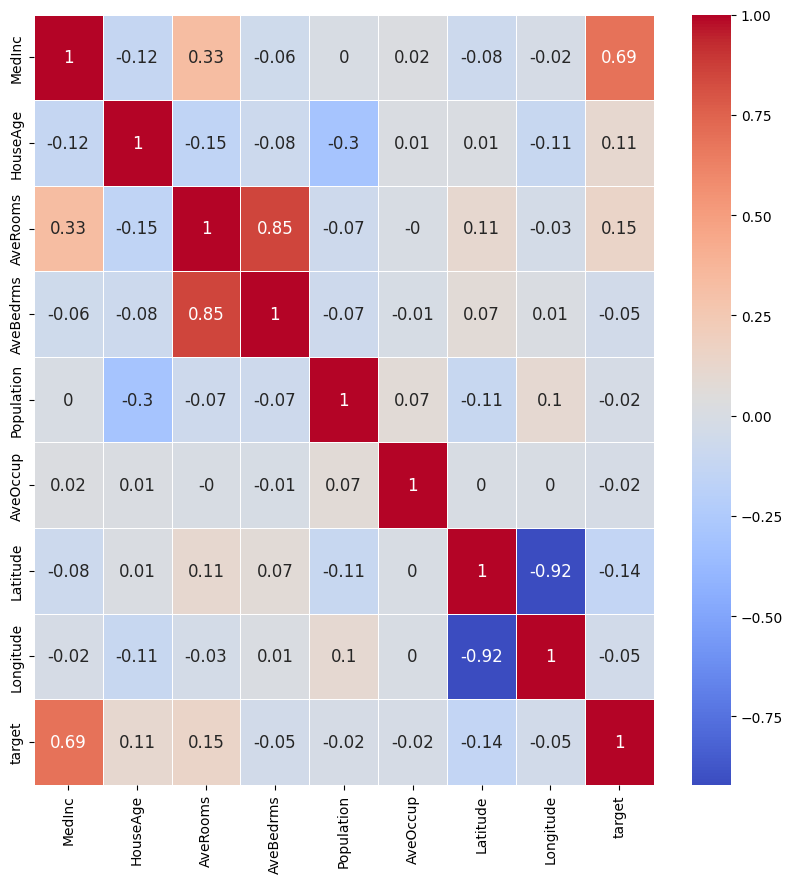

In [8]:
#We can visualise the correlation using a heatmap in Seaborn

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize = (10,10))
sns.heatmap(data=df_housing.corr().round(2), cmap='coolwarm', linewidths=.5, annot=True, annot_kws={"size":12})
plt.show()

###  Brief discussion on correlation

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
#Revisemos la data
import pandas as pd

df_q = pd.read_csv("/content/drive/MyDrive/Lab 3 - Regresión/quadratic.csv")

df_q.columns

Index(['x', 'y'], dtype='object')

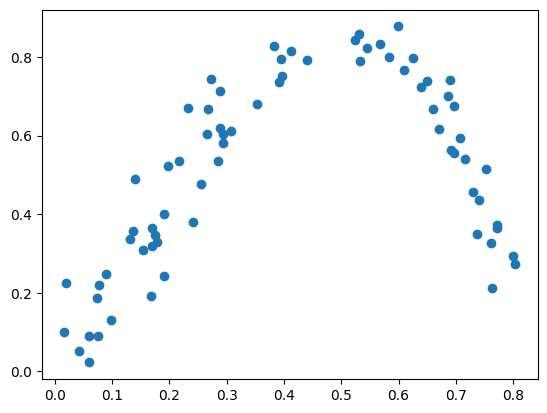

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(df_q["x"], df_q["y"], 'o')

In [15]:
df_q.corr()

,x,y
x,1.000000,0.448615
y,0.448615,1.000000


In [16]:
import math
df_q["x2"]=df_q["x"].apply(lambda x: -(x-0.5)**2)

In [17]:
df_q

,x,y,x2
0,0.154537,0.308410,-0.119345
1,0.175968,0.346179,-0.104997
2,0.140914,0.488696,-0.128943
3,0.265104,0.604524,-0.055176
4,0.232524,0.669098,-0.071544
...,...,...,...
67,0.255167,0.477284,-0.059943
68,0.198173,0.522641,-0.091099
69,0.285703,0.535777,-0.045923
70,0.306991,0.611045,-0.037253


In [18]:
df_q.corr()

,x,y,x2
x,1.000000,0.448615,0.663367
y,0.448615,1.000000,0.895750
x2,0.663367,0.895750,1.000000


In [19]:
from sklearn.linear_model import LinearRegression

simple_regr=LinearRegression()
simple_regr.fit(df_q[["x","x2"]], df_q["y"])

y_pred=simple_regr.predict(df_q[["x","x2"]])


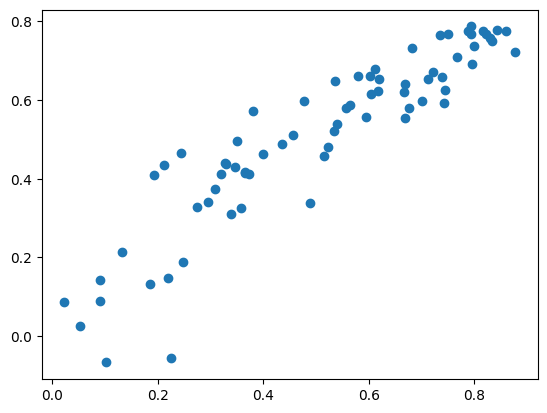

In [20]:
plt.plot(df_q["y"],y_pred,'o')

In [21]:
from sklearn import metrics

print("r2: ",metrics.r2_score(df_q["y"], y_pred ))

r2:  0.8402253913279958


## Select data

In [22]:
from sklearn.model_selection import train_test_split
import numpy as np

# Separate features and target variables
X = df_housing.iloc[:,:-1] #if I want to use all variables
y = df_housing.iloc[:,-1]

#choose your approach:
#X = df_housing.iloc[:,[0,1,2,3,4]] #if I want to use only some variable (adjust indices for California Housing)
#X = X.drop(['Population','HouseAge'], axis=1) #if I want to drop some columns
#X = X[['MedInc','AveRooms']]#if I want to select some columns
#X["MedInc2"] = np.log(X.MedInc) # Example log transform for California Housing variable

columns = X.columns #column names

In [10]:
# This line previously selected specific Boston Housing features. It has been commented out to use features defined in the previous cell.
# X=X[['RM','LSTAT2']]

# Filter the unusual observation
#X=X[y<50]
#y=y[y<50]

In [23]:
y.head(3)

,target
0,4.526
1,3.585
2,3.521


In [24]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [25]:
#Scale and select Train/Test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(copy=False).fit(X)
scaler.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=123)


In [26]:
#DEFINE YOUR REGRESSOR and THE PARAMETERS GRID
from sklearn.linear_model import LinearRegression
import numpy as np

regressor = LinearRegression() #(fit_intercept=True, normalize=False, copy_X=True, n_jobs=None)
parameters = {}

#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(regressor, parameters,cv=3) #with no params it reduces to a CV

gs = gs.fit(X_train,y_train)

#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))
means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

#test on hold-out

#gs.score(X_train, y_train)
gs.score(X_test, y_test)

***GRIDSEARCH RESULTS***
Best score: 0.529862 using {}
0.529862 (0.104402) with: {}


0.6093458386889401

<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1590/3046081917.py:3: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("Predicted prices: $\hat{y}_i$")
/tmp/ipykernel_1590/3046081917.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Prices vs Predicted prices: $y_i$ vs $\hat{y}_i$")


Text(0.5, 1.0, 'Prices vs Predicted prices: $y_i$ vs $\\hat{y}_i$')

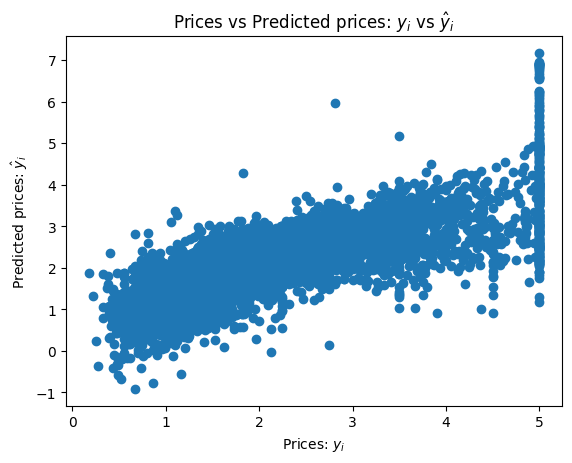

In [27]:
plt.scatter(y_test, gs.predict(X_test))
plt.xlabel("Prices: $y_i$")
plt.ylabel("Predicted prices: $\hat{y}_i$")
plt.title("Prices vs Predicted prices: $y_i$ vs $\hat{y}_i$")

In [28]:
#Independent term in the linear model.
print('Intercept: ', gs.best_estimator_.intercept_)

gs.best_estimator_.coef_

#import pandas as pd
#pd.DataFrame(list(zip(columns,gs.best_estimator_.coef_)), columns = ['features','estimatedCoefficients'])

Intercept:  2.070704236764771


array([ 0.82892237,  0.11549554, -0.25879718,  0.28921568, -0.00376872,
       -0.03854247, -0.90042289, -0.86985923])

In [29]:
from sklearn.metrics import mean_squared_error
#from sklearn.metrics import mean_squared_error

print("MSE train: ", mean_squared_error(y_train, gs.predict(X_train)))
print("MSE test: ", mean_squared_error(y_test, gs.predict(X_test)))

MSE train:  0.5278449411974971
MSE test:  0.5165766683279222


# computing MAE, MSE, RMSE, r²
 - Mean Absolute Error (MAE): $$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$
 - Mean Squared Error  (MSE): $$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$
 - Root Mean Squared Error (RMSE) : $$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

In [30]:
from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train, gs.predict(X_train)))
print("MSE train: ",metrics.mean_squared_error(y_train, gs.predict(X_train)))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, gs.predict(X_train))))
print("r2: ",metrics.r2_score(y_train, gs.predict(X_train)))

print("MAE test: ", metrics.mean_absolute_error(y_test, gs.predict(X_test)))
print("MSE test: ",metrics.mean_squared_error(y_test, gs.predict(X_test)))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, gs.predict(X_test))))
print("r2: ",metrics.r2_score(y_test, gs.predict(X_test)))

MAE train:  0.53309815905576
MSE train:  0.5278449411974971
RMSE train:  0.7265293808219301
r2:  0.604714940991568
MAE test:  0.5288160032841535
MSE test:  0.5165766683279222
RMSE test:  0.7187326821064436
r2:  0.6093458386889401


In [31]:
error_train=gs.predict(X_train)-y_train
error_test=gs.predict(X_test)-y_test

error_train.describe()

,target
count,1.444800e+04
mean,-2.870842e-16
std,7.265545e-01
min,-4.205628e+00
25%,-3.184283e-01
50%,1.291349e-01
75%,4.647615e-01
max,6.542986e+00


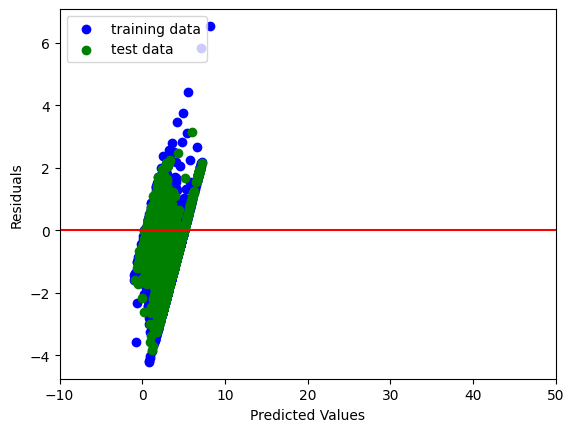

In [32]:
plt.scatter(gs.predict(X_train),error_train, c="b", label="training data")
plt.scatter(gs.predict(X_test),error_test, c="g", label="test data")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=-10, xmax=50, color="r")
plt.xlim([-10,50])
plt.show()

In [33]:
nb_error_train = np.array(error_train).flatten()

error_train = np.array(error_train).reshape(-1,1)
scaled_error_train= StandardScaler(copy=False).fit(error_train).transform(error_train).flatten()


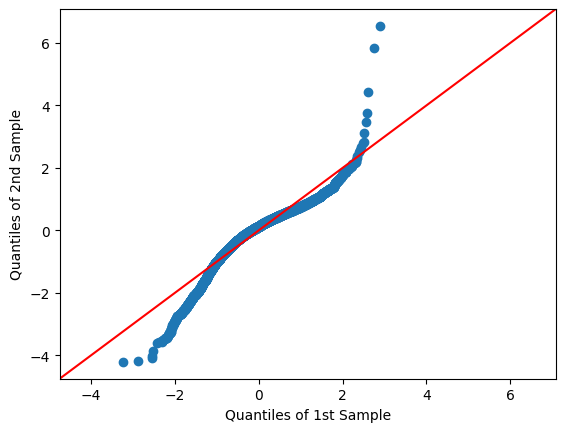

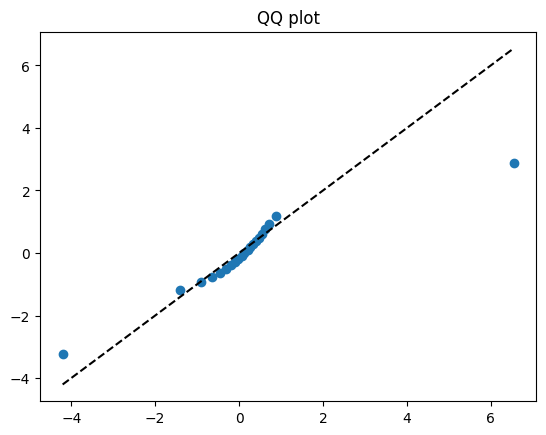

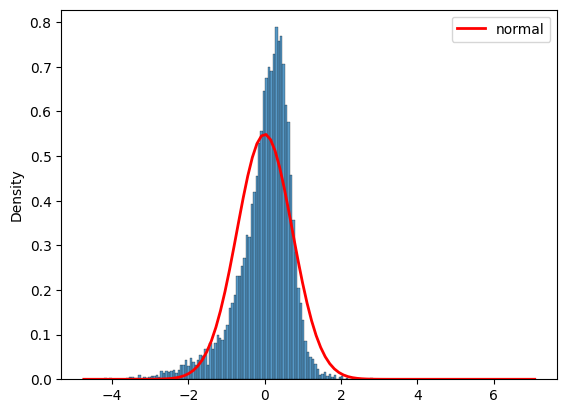

In [34]:
import numpy as np
import scipy
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot_2samples
from matplotlib import pyplot as plt

# We test a exponential distribution
dist = getattr(scipy.stats, 'norm')
param = dist.fit(nb_error_train)

err_mean=param[-2]
err_std=param[-1]

# We generate a sample of size  len(mr_scaled) of data distributed according to distribution dist
# The function rvs generates a sample with distribution dist with mean loc and std scale
test_dist = dist.rvs(*param[0:-2],loc=param[-2], scale=param[-1],size = len(nb_error_train))

# qq-plot using statsmodels
qqplot_2samples(test_dist,np.array(nb_error_train).flatten(), line='45')
plt.show()

# We create the percentiles for both distributions
test_dist.sort()
percs = np.linspace(0,100,21)
q_a = np.percentile(nb_error_train, percs)
q_b = np.percentile(test_dist, percs)

# and generate the QQ-plot
plt.plot(q_a,q_b, ls="", marker="o")
plt.title("QQ plot")
x = np.linspace(np.min((q_a.min(),q_b.min())), np.max((q_a.max(),q_b.max())))
plt.plot(x,x, color="k", ls="--")
plt.show()


# plot the distribution and compare with a normal

ax = sns.histplot(nb_error_train, stat='density')

# calculate the pdf
x0, x1 = ax.get_xlim()  # extract the endpoints for the x-axis
x_pdf = np.linspace(x0, x1, 100)
y_pdf = scipy.stats.norm.pdf(x_pdf, loc=err_mean, scale=err_std)

ax.plot(x_pdf, y_pdf, 'r', lw=2, label='normal')
ax.legend()

#plt.hist(nb_error_train,alpha=.3, density=True,bins='auto')
#plt.hist(test_dist,alpha=.3, density=True,bins='auto')
#plt.show()

In [35]:
# Kolmogorov-Smirnov Test
from scipy import stats
print(stats.kstest(scaled_error_train, "norm"))
print(stats.kstest(nb_error_train, test_dist))
# normality tests use a (0,1) normal distribution
# D'agostino normality test
print(stats.normaltest(scaled_error_train))
# Shapiro test of normality
print(stats.shapiro(scaled_error_train))

KstestResult(statistic=np.float64(0.09419318687341577), pvalue=np.float64(5.156047478548207e-112), statistic_location=np.float64(-0.11914083132259719), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.09724529346622374), pvalue=np.float64(6.483333575353697e-60), statistic_location=np.float64(-0.0852722319796957), statistic_sign=np.int8(-1))
NormaltestResult(statistic=np.float64(3079.8195470086234), pvalue=np.float64(0.0))
ShapiroResult(statistic=np.float64(0.9222752534219356), pvalue=np.float64(9.288169740765277e-65))


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14448.
  res = hypotest_fun_out(*samples, **kwds)


## Test parameters (statsmodels)

In [36]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats

X_train = sm.add_constant(X_train)
#If we want to add a constant to our model
est = sm.OLS(y_train, X_train)
est_fit = est.fit()
est_fit.params

,0
const,2.070704
MedInc,0.828922
HouseAge,0.115496
AveRooms,-0.258797
AveBedrms,0.289216
Population,-0.003769
AveOccup,-0.038542
Latitude,-0.900423
Longitude,-0.869859


In [37]:
print(est_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     2761.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:32:07   Log-Likelihood:                -15885.
No. Observations:               14448   AIC:                         3.179e+04
Df Residuals:                   14439   BIC:                         3.186e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0707      0.006    342.445      0.0

Variable Continua: Por cada unidad que aumente $X$, se espera que $Y$ varíe en promedio $\beta$ unidades, manteniendo todas las demás variables constantes (ceteris paribus).

Variable Dummy: El $\beta$ representa la diferencia promedio en la variable $Y$ entre el grupo codificado como $1$ y el grupo de referencia (codificado como $0$).

Variable Categorica: Cada $\beta$ indica la diferencia promedio de esa categoría específica frente a la categoría que quedó fuera del modelo.